In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Cleaned/finaldataset.csv")
df.drop(columns=["date"], inplace=True, errors='ignore')
df.dropna(inplace=True)
df.head()

,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [12]:
median_rate = df['FEDRates'].median()
df['FEDRates_Binary'] = (df['FEDRates'] > median_rate).astype(int)
# df.to_csv("RegressionData.csv", index=False)

In [5]:
X = df.drop(columns=['FEDRates', 'FEDRates_Binary'])
y = df['FEDRates_Binary']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

LogisticRegression()

In [9]:
y_pred = logreg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

In [10]:
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8235294117647058

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.76      0.81        85
           1       0.79      0.88      0.83        85

    accuracy                           0.82       170
   macro avg       0.83      0.82      0.82       170
weighted avg       0.83      0.82      0.82       170



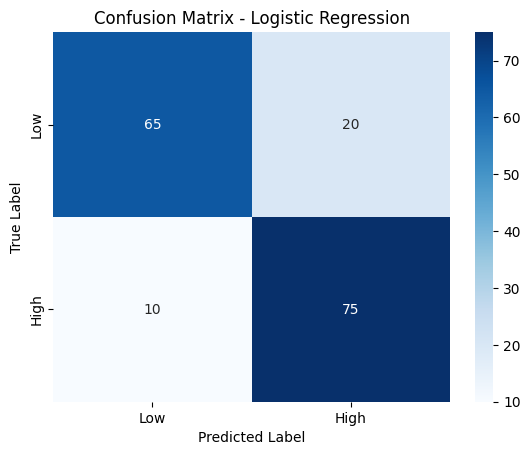

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

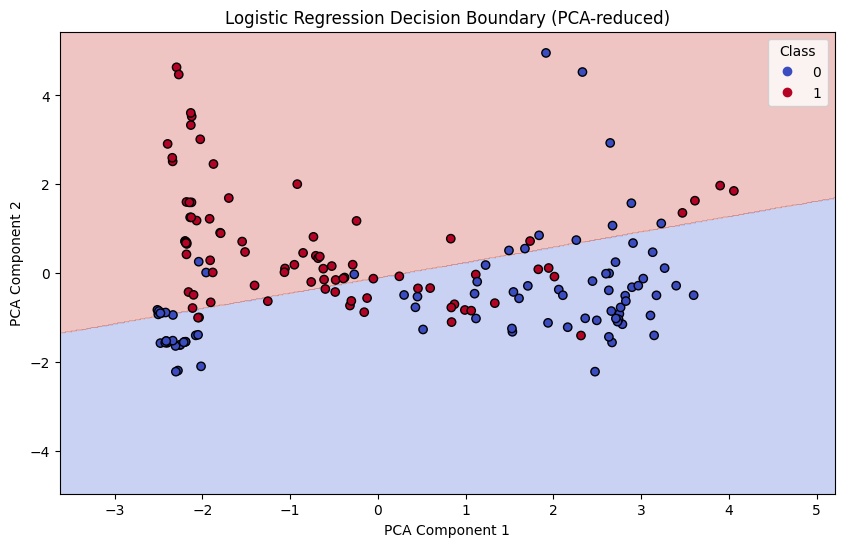

In [18]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
logreg_pca = LogisticRegression()
logreg_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
Z = logreg_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Logistic Regression Decision Boundary (PCA-reduced)")
plt.legend(*scatter.legend_elements(), title="Class")
plt.show()